## MOTORCAD AUTOMATION

### IMPORTING LIBRARIES

In [64]:
import os
import ansys.motorcad.core as pymotorcad
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as npb
import scipy.io

### VARIABLE DEFINITION
[ ONLY MODIFY THIS SECTION ]

In [83]:
file = r"C:\Users\castrglb\Documents\Automation_development\Motorcad_automation\Gen8_3pp.mot" #.mot archive to use. ****MODIFY THIS LINE****
dir_name = os.path.dirname(file) #Name of the directory where .mot is located
model_name =  os.path.splitext(os.path.basename(file))[0] #Name of the model

#Black box mode?
black_box = False

# Analysis to be performed
construccion_modelo_lab = False # Lab model
mapa_eficiencia = False # Efficiency map
balance_de_temperaturas = True
operacion_pico = False #Peak operation
operacion_continua = False #Continuous operation
operacion_transitoria = False # Transient operation

In [84]:
"""
Used units:
    Speed = [RPM] Revolutions per minute
    Current = [A] Amperes
    Voltage = [V] Volts
    Temperature = [°C] Celsius degrees
"""
#---------------------------------------------------------------Simulation parameters------------------------------------------------
#Operating mode of the machine
operating_mode = 0 #0 = motor, 1 = generator, 2 = motor/generator
control_strategy = 0 # 0 = maximum torque/amp, 1 = maximum efficiency

#Build factor losses
stator_bf = 2.17
rotor_bf = 4.03
magnet_bf = 33.19

#Lab model construction
lab_type = 0 #  0 for "Hybrid", 1 for "Full fea".
max_speed_lab = 16000 #Max speed for the lab model build
model_resolution = 1 #0 coarse, 1 fine, 2 custom
saturation_model_method = 0 #0 Curve fit, 1 interpolation

#Interpolation method (Modify this in case you choose interpolation)
current_points = 10
phase_advance_points = 6
interpolation_method = 0 #0 = Cubic spline, 1 = linear
        
#Peak operation
peak_voltage = 542 
peak_current = 650 #Maximum peak current
max_speed_emag = 16000 #Maximum speed
step_size_emag = 1000 #Speed increment size
min_speed_emag = 0 #Minimum speed

#Transient operation
transient_voltage = 542
transient_current = 650 
max_speed_trans = 16000 #Maximum speed transient
step_size_trans = 1000 #Speed increment size
min_speed_trans = 0 #Minimum speed transient
transient_duration = 10 #Duration of the operation
transient_points =  10 #Number of points

#Continuous operation
cont_voltage = 565 #Continuos voltage
cont_current = 360 #Maximum continuous current
max_speed_thermal = 16000 #Maximum speed thermal
step_size_thermal = 1000 #Speed increment size
min_speed_thermal = 0 #Minimum speed

#Temperatures
temperatura_ambiente = 100 #Ambience temperature
devanados_temperatura = 100 #Windign temperature
magnetos_temperatura = 100 #Magent temperature
flecha_temperatura = 100 # Shaft temperature
entrehierro_temperatura = 100 # Airgap temperature
stator_lam_temperature = 100 #Stator lamination temperature
rotor_lam_temperature = 100 #Rotor lamination temperature
max_temp_winding = 150 # Maximum permited temperature in the winding
max_temp_magnet = 130 # Maximum magnet temperature (This one also creates a HOTSPOT limit in the magnet of the same temperature)

#Sistemas de enfriamiento
enfriamiento = 1 #0 water jacket, 1 Slot water jacket

### ROUTINE

#### MOTORCAD OPENING

In [85]:
#Starts the program
print("Iniciando MotorCAD")
mcad = pymotorcad.MotorCAD()

#Acces to the specified file
mcad.load_from_file(file)
mcad.set_variable("Scripting_Engine", 0) # Python as the interface language

mcad.set_variable("MessageDisplayState", 2) #Disables the pupup messages
mcad.display_screen("Scripting") #Best practice to edit variables

#Simulation parameters
mcad.set_variable("OperatingMode_Lab", operating_mode)
mcad.set_variable("ControlStrat_MotorLAB", control_strategy)
mcad.set_variable("StatorIronLossBuildFactor", stator_bf)
mcad.set_variable("RotorIronLossBuildFactor", rotor_bf)
mcad.set_variable("MagnetLossBuildFactor", magnet_bf)

#Initial temperatures definition
mcad.set_variable("Initial_Machine_Temperature", temperatura_ambiente)
mcad.set_variable("ArmatureConductor_Temperature",devanados_temperatura )
mcad.set_variable("Magnet_Temperature",magnetos_temperatura)
mcad.set_variable("Shaft_Temperature", flecha_temperatura)
mcad.set_variable("Airgap_Temperature", entrehierro_temperatura)
mcad.set_variable("StatorLam_Temperature", stator_lam_temperature)
mcad.set_variable("RotorLam_Temperature", rotor_lam_temperature)

Iniciando MotorCAD


#### LAB MODEL BUILD

In [68]:
"""
This section constructs the Lab Model taking into consideration the Saturation model and Loss model
"""

if construccion_modelo_lab:
    #-------------------------------------------------------------------------------------------LAB MODEL BUILD--------------------------------------------------------------------------------
    #Model Lab Construction
    mcad.set_variable("MaxModelCurrent_RMS_MotorLAB", peak_current ) #Corriente máxima con la cual se construye el modelo lab
    mcad.set_variable("ModelBuildSpeed_MotorLAB", max_speed_lab) #Velocidad máxima para construir el modelo Lab
    mcad.set_variable("ACLossMethod_Lab", lab_type ) #Hybrid or fullfea
    mcad.set_variable("SatModelPoints_MotorLAB", model_resolution ) # Resolución del modelo
    if model_resolution == 2: # If model resolution is set to "Custom"
        mcad.set_variable("SaturationModelMethod_Lab", saturation_model_method ) #Estrategia de cálculo, 0 Curve fit, 1 interpolation
        mcad.set_variable("ModelBuildPoints_Current_Lab", current_points) # Número de puntos de corriente
        mcad.set_variable("ModelBuildPoints_Gamma_Lab", phase_advance_points) # Número de puntos de phase advance
        mcad.set_variable("SaturationModelInterpolation_Lab", 0) # Cubic spline

    mcad.set_variable("BuildSatModel_MotorLAB", True) #Build saturation model
    mcad.set_variable("BuildLossModel_MotorLAB", True) #Build loss model
    mcad.clear_model_build_lab() # Elimina el modelo anterior para evitar errores
    print("Construyendo modelo Lab")
    mcad.build_model_lab() # construcción del modelo lab

    #Redundancia de seguridad para establecer la longitud del motor usada en la construcción del modelo lab
    active_length = mcad.get_variable("Stator_Lam_Length")
    mcad.set_variable("Length_Calc_Lab", active_length)

    lab_model_build_reference = mcad.get_variable("Length_Ref_Lab")
    lab_resistance_reference = mcad.get_variable("Length_Ref_Resistance_Lab")
    active_length_used = mcad.get_variable("Length_Calc_Lab")

    print(f"Longitud activa usada en la construcción del módulo Lab: {lab_model_build_reference}")
    print(f"Longitud utilizada de referencia en modelo Lab: {lab_resistance_reference}")
    print(f"Longitud utilizada para los cálculos Lab: {active_length_used}")
    print("Modelo Lab construido")

    #Archivo base con modelo construido
    mcad.save_to_file(f"{file}") 
else:
    print()

#### HEATH BALANCE SUMMARY

In [86]:
if balance_de_temperaturas:
    print("Calculating heath balance")
    heat_balance_file = os.path.join(dir_name, f"{model_name}_heat_balance.mot")
    
    #Abrir nuevo archivo para balance de temperaturas
    mcad.save_to_file(f"{heat_balance_file}")
    mcad.load_from_file(f"{heat_balance_file}")

    #Construcción del modelo thermal lab 
    mcad.set_variable("ThermalCalcType", 0) #0 Para operación en estado estable
    mcad.set_variable("LabThermalCoupling", 2) #Acoplamiento entre modelo térmico y lab. 

    #Cálculo lab thermal
    mcad.set_variable("DCBusVoltage", cont_voltage)
    mcad.set_variable("MaxSpeedTherm_MotorLAB", max_speed_thermal)
    mcad.set_variable("SpeedStepTherm_MotorLAB", step_size_thermal)
    mcad.set_variable("MinSpeedTherm_Lab", max_speed_thermal)
    mcad.set_variable("Imax_RMS_MotorLAB", cont_current)
    mcad.set_variable("Iest_RMS_MotorLAB", cont_current)
    mcad.set_variable("MaxWindTemp_MotorLAB", max_temp_winding)
    mcad.set_variable("MaxMagnet_MotorLAB", max_temp_magnet)
    mcad.set_variable("CustomThermalLimitName_Lab", "Magnet")
    mcad.set_variable("CustomThermalLimitTemperature_Lab", max_temp_magnet)

    try:
        mcad.calculate_thermal_lab()
        print("Cálculos Lab Thermal a máxima velocidad terminados")
    except pymotorcad.MotorCADError:
        print("Existe un error en el cálculo LAB Thermal")

    mcad.save_to_file(f"{heat_balance_file}")
else:
    print()

Calculating heath balance
Cálculos Lab Thermal a máxima velocidad terminados


##### HEATH BALANCE GRAPHS

C:\Users\castrglb\AppData\Local\Temp\ipykernel_12916\652075137.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stator_copper = int(thermal_data["Stator_Copper_Loss"])
C:\Users\castrglb\AppData\Local\Temp\ipykernel_12916\652075137.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stator_iron = int(thermal_data["Iron_Loss_Stator"])
C:\Users\castrglb\AppData\Local\Temp\ipykernel_12916\652075137.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  windage = int

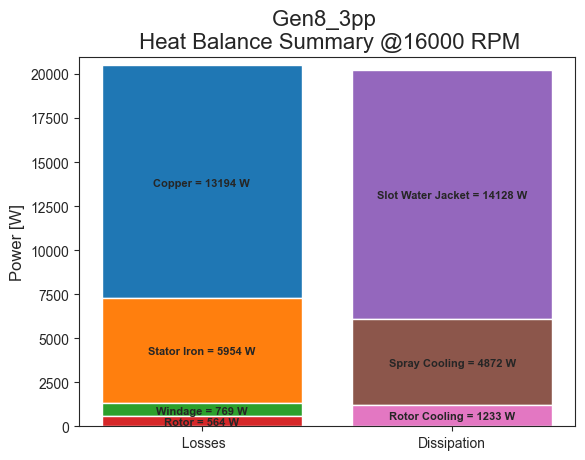

In [88]:
if balance_de_temperaturas:
    #Estracción de archivos balance de temperaturas
    thermal_data_loc = os.path.join(os.path.splitext(heat_balance_file)[0], r"Lab\MotorLAB_thermalenvdata.mat")
    thermal_data = scipy.io.loadmat(thermal_data_loc)

    #Definición de variables
    x_axis_1 = " Losses"
    x_axis_2 = "Dissipation"

    #Total Loss
    stator_copper = int(thermal_data["Stator_Copper_Loss"])
    stator_iron = int(thermal_data["Iron_Loss_Stator"])
    windage = int(thermal_data["Windage_Loss"])
    magnet = int(thermal_data["Magnet_Loss"])
    rotor_iron = int(thermal_data["Iron_Loss_Rotor"])
    rotor = magnet + rotor_iron

    #Total dissipation
    if enfriamiento == 0:
        water_jacket = int(thermal_data["Water_Jacket_Dissipation"])
        enfriamiento1 = water_jacket
        label_enfriamiento1 = "Water Jacket" 
    elif enfriamiento == 1:
        slot_water_jacket = int(mcad.get_variable("Dissipation_Slot_Water_Jacket"))
        enfriamiento1 = slot_water_jacket
        label_enfriamiento1 = "Slot Water Jacket"
    else:
        print("Define un sistema de enfriamiento")

    shaft_spiral = int(thermal_data["Shaft_Spiral_Groove_Dissipation"])
    spray_cooling = int(mcad.get_variable("Dissipation_SprayCooling_Total"))
    rotor_cooling = int(mcad.get_variable("RotorWJ_Dissipation"))

    #Height of bars list
    total_losses_list = sum([stator_copper, stator_iron, windage, rotor])
    total_dissipation_list = sum([enfriamiento1, rotor_cooling, spray_cooling])
    total_dimension_list = max(total_losses_list, total_dissipation_list)

    #Barras de Losses
    plt.bar(x_axis_1, stator_copper, bottom = (stator_iron + windage + rotor ))
    plt.bar(x_axis_1, stator_iron, bottom = (windage + rotor))
    plt.bar(x_axis_1, windage, bottom = rotor)
    plt.bar(x_axis_1, rotor)

    #Barras de Dissipation
    plt.bar(x_axis_2,enfriamiento1, bottom = (spray_cooling + rotor_cooling), label = f"{label_enfriamiento1}")
    plt.bar(x_axis_2, spray_cooling, bottom = rotor_cooling, label = "Spray Cooling")
    plt.bar(x_axis_2, rotor_cooling)

    #Etiquetas para Losses
    plt.text(x_axis_1, (stator_copper/2 + (stator_iron + windage + rotor)), f"Copper = {stator_copper} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")
    plt.text(x_axis_1, (stator_iron/2 + windage + rotor), f"Stator Iron = {stator_iron} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")
    plt.text(x_axis_1, (windage/2 + rotor), f"Windage = {windage} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")
    plt.text(x_axis_1, rotor/2, f"Rotor = {rotor} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")

    #Etiquetas para Dissipation
    plt.text(x_axis_2, (enfriamiento1/2 + spray_cooling + rotor_cooling), f"{label_enfriamiento1} = {enfriamiento1} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")
    plt.text(x_axis_2, (spray_cooling/2 + rotor_cooling), f"Spray Cooling = {spray_cooling} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")
    plt.text(x_axis_2, rotor_cooling/2, f"Rotor Cooling = {rotor_cooling} W", ha = "center", va = "center_baseline", size = 8, weight = "bold")

    #Títulos
    plt.title(f"{model_name} \n Heat Balance Summary @{max_speed_thermal} RPM", size = 16)
    plt.ylabel("Power [W]", size = 12)
    plt.ylim(0,total_dimension_list + 500)

    #Crear la dirección para guardar archivos "Heat balance"
    graphs_folder_name = "Graphs"
    graphs_folder_path = os.path.join(dir_name, graphs_folder_name)
    if not os.path.exists(graphs_folder_path):
        os.mkdir(graphs_folder_path)

    #Blance térmico figura
    heat_balance_file_name = "heat_balance.png"
    output_path_heat_balance = os.path.join(graphs_folder_path, heat_balance_file_name)
    plt.savefig(output_path_heat_balance, dpi = 300, bbox_inches = "tight")

    if black_box == False:
        #Capturas de pantalla
        mcad.show_thermal_context()
        mcad.initialise_tab_names()
        mcad.display_screen("Temperatures;Axial")

        #axial
        axial_temperatures_file_name = "axial_temperatures.png"
        output_path_axial_temperatures = os.path.join(graphs_folder_path, axial_temperatures_file_name)
        mcad.save_motorcad_screen_to_file("Temperatures;Axial",output_path_axial_temperatures)

        #Radial
        radial_temperatures_file_name = "radial_temperatures.png"
        output_path_radial_temperatures = os.path.join(graphs_folder_path, radial_temperatures_file_name)
        mcad.save_motorcad_screen_to_file("Temperatures;Radial",output_path_radial_temperatures)

    mcad.save_to_file(f"{heat_balance_file}")
else:
    print()

In [90]:
print(f"Total thermal load = {total_losses_list} W")

Total thermal load = 20481 W


#### THERMAL LAB OPERATION

In [71]:
"""
This section constructs the lab thermal operation, for steady state calculations
"""
if operacion_continua:
    mcad.load_from_file(file)

    #Características de la operación térmica
    mcad.set_variable("ThermalCalcType", 0) #0 for steady state operation
    mcad.set_variable("LabThermalCoupling", 2) #2 Coupling between lab and thermal model

    #Cálculo lab thermal
    mcad.set_variable("DCBusVoltage", cont_voltage)
    mcad.set_variable("MaxSpeedTherm_MotorLAB", max_speed_thermal)
    mcad.set_variable("SpeedStepTherm_MotorLAB", step_size_thermal)
    mcad.set_variable("MinSpeedTherm_Lab", min_speed_thermal)
    mcad.set_variable("Imax_RMS_MotorLAB", cont_current)
    mcad.set_variable("Iest_RMS_MotorLAB", cont_current)
    mcad.set_variable("MaxWindTemp_MotorLAB", max_temp_winding)
    mcad.set_variable("MaxMagnet_MotorLAB", max_temp_magnet)
    mcad.set_variable("CustomThermalLimitName_Lab", "Magnet")
    mcad.set_variable("CustomThermalLimitTemperature_Lab", max_temp_magnet)

    try:
        mcad.calculate_thermal_lab()
        print("Cálculo Lab Thermal realizado con éxito")
    except pymotorcad.MotorCADError:
        print("Existe un error en el cálculo LAB Thermal")

    mcad.save_to_file(file)
else:
    print()

#### EFFICIENCY MAP

In [72]:
if mapa_eficiencia and not(black_box):
    #Cálculo de mapa de eficiencia
    mcad.set_variable("EmagneticCalcType_Lab",1)
    mcad.set_variable("SmoothMap_MotorLAB", True)
    mcad.set_variable("SpeedMax_MotorLAB", max_speed_emag)
    mcad.set_variable("Speedinc_MotorLAB", 100)
    mcad.set_variable("SpeedMin_MotorLAB", min_speed_emag)
    mcad.set_variable("Imax_RMS_MotorLAB", peak_current)
    mcad.set_variable("Iinc_MotorLAB", 200)
    mcad.set_variable("Imin_RMS_MotorLAB", 0)

    try:
        mcad.calculate_magnetic_lab()
        print("Mápa de eficiencia realizado con éxito")
    except pymotorcad.MotorCADError:
        print("Error en el cálculo LAB Emag")

    #Guardar la figura
    graphs_folder_name = "Graphs"
    graphs_folder_path = os.path.join(dir_name, graphs_folder_name)
    if not os.path.exists(graphs_folder_path):
        os.mkdir(graphs_folder_path)

    efficiency_map_file_name = r"efficiency_map.png"
    output_path_efficiency_map = os.path.join(graphs_folder_path, efficiency_map_file_name)
    mcad.export_figure_lab("Electromagnetic", "Efficiency", output_path_efficiency_map)

    mcad.save_to_file(file)
else:
    print()

#### EMAG LAB OPERATION

In [73]:
"""
This seaction calcualtes the peak performance (Only electromagnetic) from the lab electromagnetic
"""
if operacion_pico:
    mcad.load_from_file(file)
    #Cálculo lab emag
    mcad.set_variable("EmagneticCalcType_Lab", 0)
    mcad.set_variable("SpeedMax_MotorLAB", max_speed_emag)
    mcad.set_variable("Speedinc_MotorLAB", step_size_emag)
    mcad.set_variable("SpeedMin_MotorLAB", min_speed_emag)
    mcad.set_variable("DCBusVoltage", peak_voltage)
    mcad.set_variable("Imax_RMS_MotorLAB", peak_current)

    try:
        mcad.calculate_magnetic_lab()
        print("Cálculo Lab Emag realizado con éxito")
    except pymotorcad.MotorCADError:
        print("Error en el cálculo LAB Emag")

    #Redundance of security to establish length used in lab calculations same as length of model build
    #Redundancia de seguridad para asegurar que la longitud axial utilizada para los cálculos sea la misma que con la que se construyó el modelo Lab
    lab_model_build_reference = mcad.get_variable("Length_Ref_Lab")
    lab_resistance_reference = mcad.get_variable("Length_Ref_Resistance_Lab")
    active_length_used = mcad.get_variable("Length_Calc_Lab")

    print(f"Longitud activa usada en la construcción del módulo Lab: {lab_model_build_reference}")
    print(f"Resistencia de referencia usada en los cálculos Lab: {lab_resistance_reference}")
    print(f"Longitud activa utilizada en cálculos Lab: {active_length_used}")

    mcad.save_to_file(f"{file}")
else:
    print()

Cálculo Lab Emag realizado con éxito
Longitud activa usada en la construcción del módulo Lab: 198
Resistencia de referencia usada en los cálculos Lab: 198
Longitud activa utilizada en cálculos Lab: 198


#### TRANSIENT OPERATION

In [74]:
"""
Transient operation from the Lab thermal section
"""
transient_file = os.path.join(dir_name, f"{model_name}_{transient_duration}s.mot")
if operacion_transitoria:
    mcad.save_to_file(f"{transient_file}")
    mcad.load_from_file(f"{transient_file}")

    #Establece operación transitoria
    mcad.set_variable("ThermalCalcType", 1) #1 = transitoria
    mcad.set_variable("ThermalModelSize", 0)
    mcad.set_variable("ThermalModelType", 0)
    
    mcad.set_variable("TransientCalculationType", 0) #0 = Transitorio simple, 1 = Transitorio Duty Cycle
    mcad.set_variable("Simple_Transient_Period", transient_duration) # Duración en segundos del análisis transitorio
    mcad.set_variable("Simple_Transient_Number_Points", transient_points)
    mcad.set_variable("Simple_Transient_Definition", 1 ) # actua en función del torque
    mcad.set_variable("InitialTransientTemperatureOption", 3 ) #3 = Toda la máquina a la misma temperatura
    mcad.set_variable("Initial_Machine_Temperature", temperatura_ambiente)
    mcad.set_variable("EndPoint_Definition", 0)  # O = Tiene una duración determinada de tiempo, 1 = hasta alcanzar temperaturas estables 

    mcad.set_variable("ThermalMapType_Lab", 0) #Envelope
    mcad.set_variable("ThermCalcType_MotorLAB", 1) #1 = transitoria

    #Thermal limit
    mcad.set_variable("TempLimit_MotorLAB",1) # 1 = Límite térmico en el devanado y los magnetos
    mcad.set_variable("MaxWindingSpec_MotorLAB", 1) #1 = Límite en un punto caliente y no en temepratura promediode los devanados
    mcad.set_variable("CustomThermalLimitName_Lab", "Magnet") #Límite de temperatura en punto caliente de los magnetos
    mcad.set_variable("CustomThermalLimitTemperature_Lab", max_temp_magnet) # Límite en punto caliente igual al promedio

    #Speed
    mcad.set_variable("MaxSpeedTherm_MotorLAB", max_speed_trans)
    mcad.set_variable("SpeedStepTherm_MotorLAB", step_size_trans)
    mcad.set_variable("MinSpeedTherm_Lab", min_speed_trans)

    #Maximum Temperatures
    mcad.set_variable("MaxWindTemp_MotorLAB", max_temp_winding)
    mcad.set_variable("MaxMagnet_MotorLAB", max_temp_magnet)

    #Maximum current
    mcad.set_variable("Imax_RMS_MotorLAB", transient_current)
    mcad.set_variable("Iest_RMS_MotorLAB", transient_current)
    mcad.set_variable("DCBusVoltage", transient_voltage)
    
    print("Calculando operación transitoria")

    try:
        mcad.calculate_thermal_lab()
        print("Cálculo transitorio realizado con éxito")
    except pymotorcad.MotorCADError:
        print("Existe un error en el cálculo transitorio")
    
    mcad.save_to_file(transient_file)
else:
    print()

#### FILES SAVING AND MOTORCAD CLOSING

In [75]:
#Save the file for security
mcad.quit()
print("Simulación terminada")

Simulación terminada


### RESULTS GRAPHS

#### FILES EXTRACTION

In [76]:
if operacion_pico:
    emag_data_loc = os.path.join(os.path.splitext(file)[0], r"lab", r"MotorLAB_elecdata.mat")
    print("Peak operation files location:")
    print("    " + emag_data_loc)
    emag_data = scipy.io.loadmat(emag_data_loc)

if operacion_continua:
    thermalenv_data_loc = os.path.join(os.path.splitext(file)[0], r"lab", r"MotorLAB_thermalenvdata.mat")
    print("Continuous operation files location:")
    print("    " + thermalenv_data_loc)
    thermal_data = scipy.io.loadmat(thermalenv_data_loc)

if operacion_transitoria:
    transient_file = os.path.join(dir_name, f"{model_name}_{transient_duration}s.mot")
    thermalenv_data_loc = os.path.join(os.path.splitext(transient_file)[0], r"lab", r"MotorLAB_thermalenvdata.mat")
    print("Transient operation files location:")
    print("    " + thermalenv_data_loc)
    transient_data = scipy.io.loadmat(thermalenv_data_loc)

Peak operation files location:
    C:\Users\castrglb\Documents\Automation_development\Motorcad_automation\Gen8_3pp\lab\MotorLAB_elecdata.mat


#### PEAK PERFORMANCE

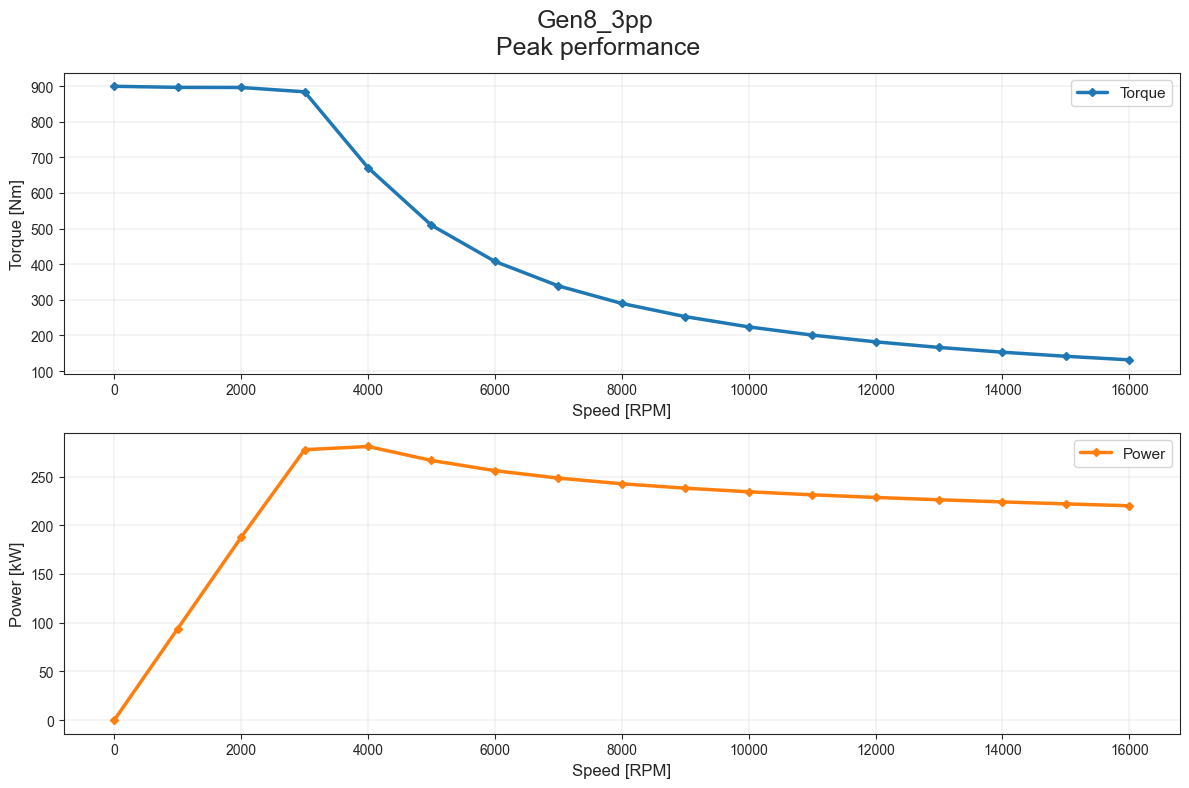

In [77]:
if operacion_pico:

    #VARIABLE DEFINITION
    speed = emag_data["Speed"]
    power = emag_data["Shaft_Power"]
    torque = emag_data["Shaft_Torque"]

    #GRAPH DEFINITION
    sns.set_style("ticks") #DEFINE EL ESTILO SEABORN ticks

    # Crear una figura con dos subplots
    fig, axs = plt.subplots(2, figsize=(12, 8))

    # Subplot 1: Torque pico y Potencia pico
    axs[0].plot(speed[::], torque[::], label="Torque", marker="D", ms="4.2", color = "C0", lw = 2.5)
    axs[0].set_ylabel("Torque [Nm]", fontsize = 12)
    axs[0].set_xlabel("Speed [RPM]", fontsize = 12)
    axs[0].legend(loc="best", fontsize = 11)
    axs[0].grid(True, lw = 0.3)

    axs[1].plot(speed[::], power[::], label="Power", marker="D", ms="4.2", color = "C1", lw = 2.5)
    axs[1].set_ylabel("Power [kW]", fontsize = 12)
    axs[1].set_xlabel("Speed [RPM]", fontsize = 12)
    axs[1].legend(loc="best", fontsize = 11)
    axs[1].grid(True, lw = 0.3)

    #Título general
    plt.suptitle(f"{model_name}\n Peak performance", fontsize = 18, fontweight = "light",)

    # Ajustar espaciado entre subplots
    plt.tight_layout()

    #Salvar gráficas
    graphs_folder_name = "Graphs"
    graphs_folder_path = os.path.join(dir_name, graphs_folder_name)
    if not os.path.exists(graphs_folder_path):
        os.mkdir(graphs_folder_path)

    peak_performance_file_name = "peak_performance.png"
    output_path_peak_performance = os.path.join(graphs_folder_path, peak_performance_file_name)
    plt.savefig(output_path_peak_performance, dpi = 300, bbox_inches = "tight")

else:
    print()

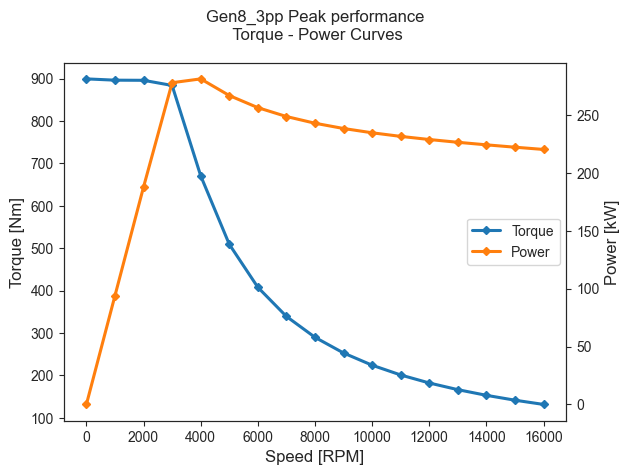

In [78]:
if operacion_pico:
    #Combined graphs [Torque / Power]
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Speed [RPM]', size = 12)
    ax1.set_ylabel('Torque [Nm]', size = 12)
    ax1.plot(speed, torque, label="Torque", lw=2.2, marker="D", ms=4.2, color = "C0")
    #ax1.tick_params(axis='y')

    ax2 = ax1.twinx()  
    ax2.set_ylabel('Power [kW]', size = 12)  
    ax2.plot(speed, power, label="Power", lw=2.2, marker="D", ms=4.2, color = "C1")

    fig.suptitle(f"{model_name} Peak performance\n Torque - Power Curves", size = 12)
    fig.tight_layout() 

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

    peak_performance_file_name = "peak_performance_torque_power.png"
    output_path_peak_performance = os.path.join(graphs_folder_path, peak_performance_file_name)
    plt.savefig(output_path_peak_performance, dpi = 300, bbox_inches = "tight")
else:
    print()

#### CONTINUOUS PERFORMANCE Y TEMPERATURAS MÁXIMAS

In [79]:
if operacion_continua:
    sns.set_style("ticks") #DEFINE EL ESTILO SEABORN ticks
    
    #DEFINICIÓN DE VARIABLES A GRAFICAR
    speed = thermal_data["Speed"]
    torque = thermal_data["Shaft_Torque"]
    power = thermal_data["Shaft_Power"]
    speed = thermal_data["Speed"]
    magnet_temp = thermal_data["Magnet_Temp_Max"]
    winding_temp = thermal_data["Stator_Winding_Temp_Max"]

    fig, axs = plt.subplots(2, figsize=(12, 8))

    # Subplot 1: Torque pico y Potencia pico
    axs[0].plot(speed, torque, label="Torque", marker="D", ms="4.2", color = "C0", lw = 2.2)
    axs[0].set_ylabel("Torque [Nm]", fontsize = 12)
    axs[0].set_xlabel("Speed [RPM]", fontsize = 12)
    axs[0].legend(loc="best", fontsize = 11)
    axs[0].grid(True, lw = 0.3)

    axs[1].plot(speed, power, label="Power", marker="D", ms="4.2", color = "C1", lw = 2.2)
    axs[1].set_ylabel("Power [kW]", fontsize = 12)
    axs[1].set_xlabel("Speed [RPM]", fontsize = 12)
    axs[1].legend(loc="best", fontsize = 11)
    axs[1].grid(True, lw = 0.3)

    #Título general
    plt.suptitle(f"{model_name}\n Continuous performance", fontsize = 18, fontweight = "light")

    # Ajustar espaciado entre subplots
    plt.tight_layout()

    #Salvar gráficas
    graphs_folder_name = "Graphs"
    graphs_folder_path = os.path.join(dir_name, graphs_folder_name)
    if not os.path.exists(graphs_folder_path):
        os.mkdir(graphs_folder_path)

    continuous_performance_file_name = "continuous_performance.png"
    output_path_continuous_performance = os.path.join(graphs_folder_path, continuous_performance_file_name)
    plt.savefig(output_path_continuous_performance, dpi = 300, bbox_inches = "tight")

    #Gráfica de temperaturas
    plt.figure(figsize=(12,4))
    plt.plot(speed, magnet_temp, label = " Magnet max. temp.", color = "C0", lw = 2.2, marker = "D",ms = 4.2)
    plt.plot(speed, winding_temp, label = "Winding max. temp.", color = "C1", lw = 2.2, marker = "D",ms = 4.2)
    plt.legend(loc = "best", fontsize = 11)

    plt.title(f"{model_name} continuous performance\n Magnet and winding temperatures", fontsize = 18, fontweight = "light")
    plt.ylabel("Temperature [°C]", size = 12)
    plt.xlabel("Speed [RPM]", size = 12)
    plt.grid(True, lw = 0.3)

    max_temps_file_name = "continuous_max_temperatures.png"
    output_path_max_temps = os.path.join(graphs_folder_path, max_temps_file_name)
    plt.savefig(output_path_max_temps, dpi = 300, bbox_inches = "tight")
    plt.show()

else:
    print()

In [80]:
if operacion_continua:
    #Combined graphs [Torque / Power]
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Speed [RPM]', size = 12)
    ax1.set_ylabel('Torque [Nm]', size = 12)
    ax1.plot(speed, torque, label="Torque", lw=2.2, marker="D", ms=4.2, color = "C0")
    #ax1.tick_params(axis='y')

    ax2 = ax1.twinx()  
    ax2.set_ylabel('Power [kW]', size = 12)  
    ax2.plot(speed, power, label="Power", lw=2.2, marker="D", ms=4.2, color = "C1")

    fig.suptitle(f"{model_name} Continuous performance\n Torque - Power Curves", size = 12)
    fig.tight_layout() 

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

    continuous_performance_file_name = "continuous_performance_torque_power.png"
    output_path_continuous_performance = os.path.join(graphs_folder_path, continuous_performance_file_name)
    plt.savefig(output_path_continuous_performance, dpi = 300, bbox_inches = "tight")
else:
    print()

#### TRANSIENT OPERATION

In [81]:
if operacion_transitoria:
    sns.set_style("ticks") #DEFINE EL ESTILO SEABORN ticks
    
    #DEFINICIÓN DE VARIABLES A GRAFICAR
    speed = transient_data["Speed"]
    torque = transient_data["Shaft_Torque"]
    power = transient_data["Shaft_Power"]
    speed = transient_data["Speed"]
    magnet_temp = transient_data["Magnet_Temp_Max"]
    winding_temp = transient_data["Stator_Winding_Temp_Max"]

    fig, axs = plt.subplots(2, figsize=(12, 8))

    # Subplot 1: Torque transitorio
    axs[0].plot(speed, torque, label="Torque", marker="D", ms="4.2", color = "C0", lw = 2.2)
    axs[0].set_ylabel("Torque [Nm]", fontsize = 12)
    axs[0].set_xlabel("Speed [RPM]", fontsize = 12)
    axs[0].legend(loc="best", fontsize = 11)
    axs[0].grid(True, lw = 0.3)

    axs[1].plot(speed, power, label="Power", marker="D", ms="4.2", color = "C1", lw = 2.2)
    axs[1].set_ylabel("Power [kW]", fontsize = 12)
    axs[1].set_xlabel("Speed [RPM]", fontsize = 12)
    axs[1].legend(loc="best", fontsize = 11)
    axs[1].grid(True, lw = 0.3)

    #Título general
    plt.suptitle(f"{model_name} {transient_duration}s\n Transient operation", fontsize = 18, fontweight = "light")

    # Ajustar espaciado entre subplots
    plt.tight_layout()

    #Salvar gráficas
    graphs_folder_name = "Graphs"
    graphs_folder_path = os.path.join(dir_name, graphs_folder_name)
    if not os.path.exists(graphs_folder_path):
        os.mkdir(graphs_folder_path)

    transient_performance_file_name = f"transient{transient_duration}s_performance.png"
    output_path_transient_performance = os.path.join(graphs_folder_path, transient_performance_file_name)
    plt.savefig(output_path_transient_performance, dpi = 300, bbox_inches = "tight")

    #Gráfica de temperaturas
    plt.figure(figsize=(12,4))
    plt.plot(speed, magnet_temp, label = " Magnet max. temp.", color = "C0", lw = 2.2, marker = "D",ms = 4.2)
    plt.plot(speed, winding_temp, label = "Winding max. temp.", color = "C1", lw = 2.2, marker = "D",ms = 4.2)
    plt.legend(loc = "best", fontsize = 11)

    plt.title(f"{model_name} {transient_duration}s transient\n Magnet and winding temperatures", fontsize = 18, fontweight = "light")
    plt.ylabel("Temperature [°C]", size = 12)
    plt.xlabel("Speed [RPM]", size = 12)
    plt.grid(True, lw = 0.3)

    max_temps_file_name = f"transient{transient_duration}s_max_temperatures.png"
    output_path_max_temps = os.path.join(graphs_folder_path, max_temps_file_name)
    plt.savefig(output_path_max_temps, dpi = 300, bbox_inches = "tight")
    plt.show()

else:
    print()

In [82]:
if operacion_transitoria:
    #Combined graphs [Torque / Power]
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('Speed [RPM]', size = 12)
    ax1.set_ylabel('Torque [Nm]', size = 12)
    ax1.plot(speed, torque, label="Torque", lw=2.2, marker="D", ms=4.2, color = "C0")
    #ax1.tick_params(axis='y')

    ax2 = ax1.twinx()  
    ax2.set_ylabel('Power [kW]', size = 12)  
    ax2.plot(speed, power, label="Power", lw=2.2, marker="D", ms=4.2, color = "C1")

    fig.suptitle(f"{model_name} Transient performance\n Torque - Power Curves", size = 12)
    fig.tight_layout() 

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

    transient_performance_file_name = f"transient_{transient_duration}s_torque_power.png"
    output_path_transient_performance = os.path.join(graphs_folder_path, transient_performance_file_name)
    plt.savefig(output_path_transient_performance, dpi = 300, bbox_inches = "tight")